<a href="https://colab.research.google.com/github/hirenpatel1404/AI_lab/blob/main/Lesson_7_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Hiren Patel
##Assignment 7: House Price Prediction Using Boston Housing Data

I'm predicting Boston house prices. The price is a number, so this is regression — I'm predicting a value, not sorting things into groups. And the data already has the real prices for the model to learn from, so it's supervised learning.

#Part 1 — Imports

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
#from sklearn.datasets import load_boston
from sklearn.model_selection import GridSearchCV

###Interpretation of Part 1 (Imports):

Before starting, I brought in the tools I need: pandas and numpy for the data, matplotlib and seaborn for charts, and the sklearn pieces for splitting the data, building the model, and scoring it. Since this is a supervised regression problem using a tree-based model, I imported Random Forest and the regression metrics.

#Part 2 Data Collection and Loading

In [8]:
# NOTE: load_boston() was removed from sklearn due to ethical concerns,
# so we load the Boston data from kaggel
df = pd.read_csv('housing.csv')
# Correct column names in order
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
                'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

In [10]:
# Reload: no header row, split on spaces, apply our names
df = pd.read_csv("housing.csv",
                 header=None,
                 sep=r"\s+",
                 names=column_names)

#Part 3 Quick Check of Data

In [11]:
# Display the first few rows to see the structure
df.head()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [12]:
# Check data types and non-null counts for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [13]:
# Statistical summary (mean, min, max, quartiles) for each column
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


###Interpretation of Part 2 & 3 (Quick Check of Data):

When I first loaded the data with .head(), I noticed the dataset had no column names — the first row of actual data was being used as the header, and all the values were squished into one column because the file was space-separated, not comma-separated. To fix this, I defined the correct column names in order and reloaded the CSV using header=None (so no data row is treated as a header), sep=r"\s+" (to split the values on spaces), and names=column_names (to apply the proper labels). After this, the data displayed correctly as 14 clean, named columns.

I then checked the data further using .info() to confirm the data types and check for missing values, and .describe() to see the statistical summary of each column. Almost all features are continuous measured amounts (like crime rate, rooms, and tax rate), except CHAS, which is categorical — it only takes 0 or 1 depending on whether the area borders the Charles River. The target MEDV is continuous, which fits a regression problem.

#EDA and Data Preprocessing

In [14]:
# Check for missing/null values in each column
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


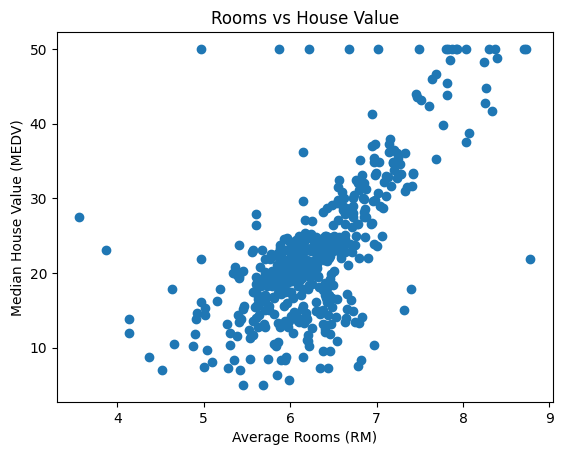

In [15]:
# Visualize one relationship: average rooms (RM) vs house value (MEDV)
plt.scatter(df['RM'], df['MEDV'])
plt.xlabel('Average Rooms (RM)')
plt.ylabel('Median House Value (MEDV)')
plt.title('Rooms vs House Value')
plt.show()

In [ ]:
# Function to automate scatter plots for any feature vs the target
def plot_feature_vs_target(features_list, target):
  for feature_name in features_list:
    plt.scatter(df[feature_name], df[target])
    plt.xlabel(feature_name)
    plt.ylabel(target)
    plt.title(f'{feature_name} vs {target}')
    plt.show()

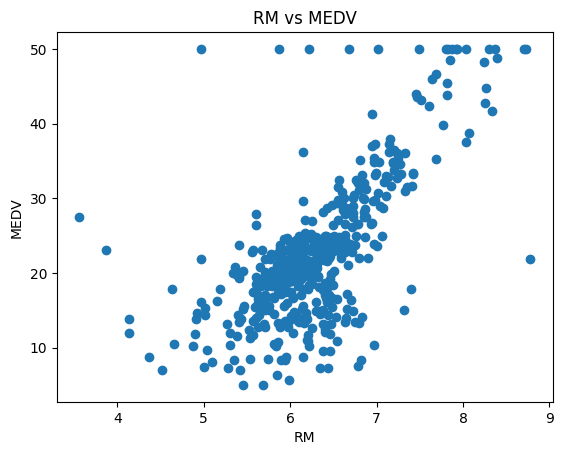

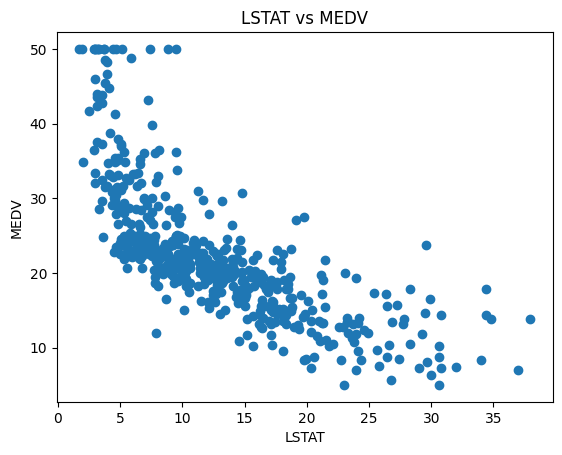

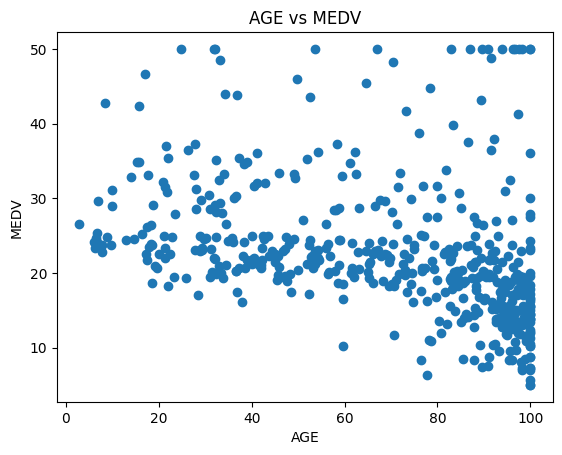

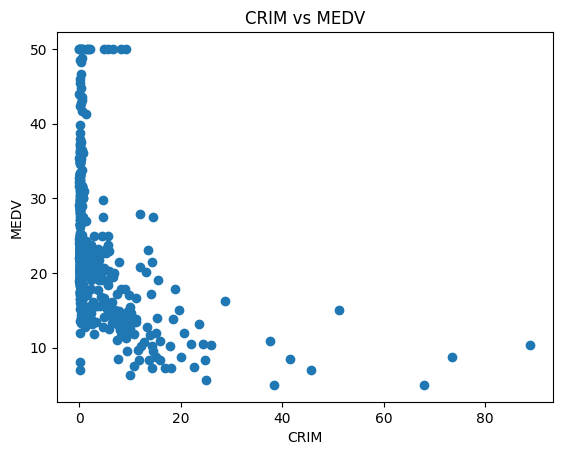

In [19]:
# Visualize multiple features against the target
features_to_plot = ['RM', 'LSTAT', 'AGE', 'CRIM']
plot_feature_vs_target(features_to_plot, 'MEDV')

In [20]:
# Check how strongly each feature correlates with the target (MEDV)
df.corr()['MEDV'].sort_values(ascending=False)

,MEDV
MEDV,1.000000
RM,0.695360
ZN,0.360445
B,0.333461
DIS,0.249929
CHAS,0.175260
AGE,-0.376955
RAD,-0.381626
CRIM,-0.388305
NOX,-0.427321


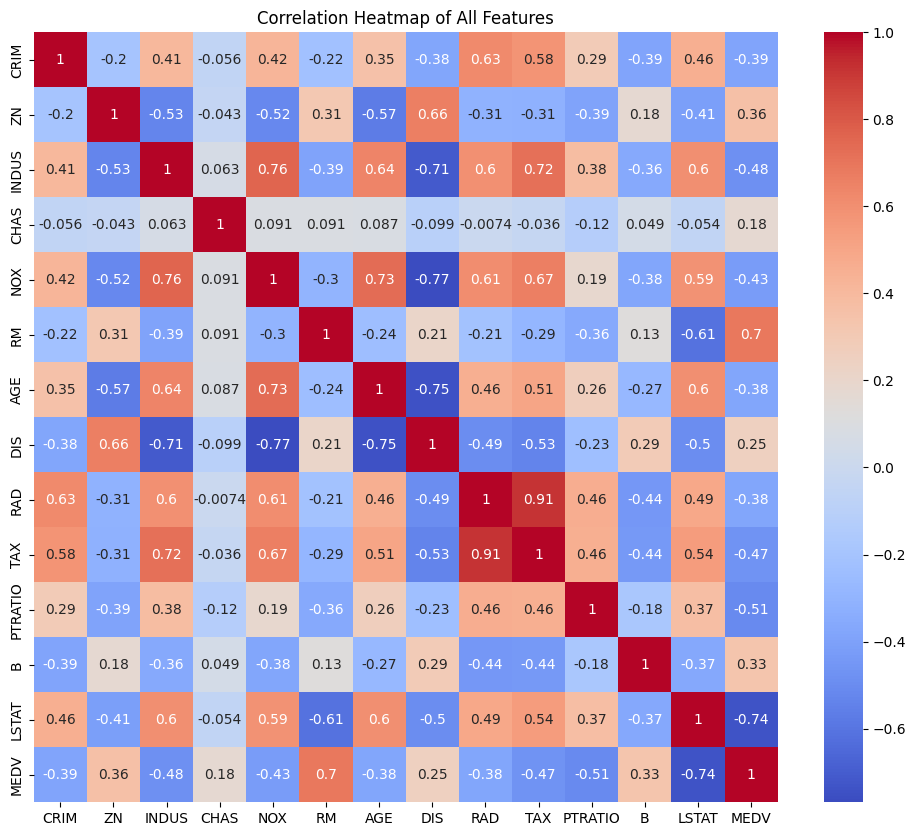

In [22]:
# Correlation heatmap: how every feature relates to every other feature
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of All Features')
plt.show()

###Interpretation of Part 4 (EDA and Data Preprocessing):

I checked for missing values with .isnull().sum(), then explored the data both visually and numerically. Using scatter plots — automated with a function that loops through a list of features — I looked at how each feature relates to house value. RM (average rooms) showed a clear upward trend, meaning more rooms tends to mean a higher value, while LSTAT (percentage of lower-status population) showed a strong downward trend, meaning a higher LSTAT tends to mean a lower value. I confirmed these numerically with .corr() on the target and used a correlation heatmap to view all relationships at once, which also helps spot features that are related to each other. Overall, RM and LSTAT stand out as the strongest predictors of house value.

# ML Model Training

In [23]:
# Define features (X) and target (y)
X = df.drop('MEDV', axis=1)
y = df['MEDV']

In [24]:
# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
# Choose the model: Random Forest Regressor
model = RandomForestRegressor(random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

###Interpretation of Part 5 (ML Model Training):

I separated the data into features (X) — all columns except MEDV — and the target (y), which is the house value. I then split the data into an 80% training set and a 20% test set, holding the test set aside so I could evaluate the model fairly on unseen data. I chose a Random Forest Regressor because it's a strong model for regression: it builds many decision trees, each making its own prediction, and averages them together for a more accurate and stable result than a single tree. I trained it on the training data using .fit().

#Model Evaluation

In [26]:
# --- Model Evaluation ---
# Predict on the test set (data the model never saw)
y_pred = model.predict(X_test)

# Calculate RMSE and R-squared
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Basic Model RMSE:", rmse)
print("Basic Model R-squared:", r2)

Basic Model RMSE: 2.8109631609391226
Basic Model R-squared: 0.8922527442109116


In [28]:
#Parameter tuning
#GridSearchCV to find better settings

param_grid = {
    'n_estimators': [50, 100, 200],        # number of trees
    'max_depth': [5, 10, 20, None],        # how deep each tree can grow
    'min_samples_split': [2, 5, 10]        # min samples needed to split a node
}

# Search every combination using 5-fold cross-validation on the TRAINING data
grid_search = GridSearchCV(RandomForestRegressor(random_state=42),
                           param_grid,
                           cv=5,
                           scoring='r2',
                           n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV R-squared:", grid_search.best_score_)

Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV R-squared: 0.8260974564965702


In [29]:
#Evaluate the tuned model
# Use the best model found by the search
best_model = grid_search.best_estimator_

# Predict and score on the test set
y_pred_tuned = best_model.predict(X_test)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned Model RMSE:", rmse_tuned)
print("Tuned Model R-squared:", r2_tuned)

Tuned Model RMSE: 2.8109631609391226
Tuned Model R-squared: 0.8922527442109116


####RMSE 2.81 → the model's price predictions are typically off by about $2,810. Small, given house values run from ~$5k to $50k.

####R² 0.89 → the model explains about 89% of the variation in house prices. Strong fit.


###Interpretation of Part 6 (Model Evaluation + Tuning)

I evaluated the basic Random Forest on the test set and got an RMSE of 2.81 and an R-squared of 0.89. Since MEDV is measured in $1,000s, an RMSE of 2.81 means the model's predictions are typically off by about $2,810, and an R-squared of 0.89 means the model explains about 89% of the variation in house prices — a strong fit.

I then performed parameter tuning using GridSearchCV, testing many combinations of the number of trees, maximum tree depth, and minimum samples to split, with cross-validation on the training data. The tuned model produced the same scores as the basic model (RMSE 2.81, R-squared 0.89). This means the default Random Forest settings were already near-optimal for this dataset, so tuning did not improve performance further. This is a valid outcome — it shows that Random Forest performed well out-of-the-box, and on this clean, relatively small dataset there was little room for tuning to gain more.

#Model Prediction


In [31]:
# Three new houses (each row = one house)
# Order: CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TAX, PTRATIO, B, LSTAT
new_houses = [
    [0.2, 12.5, 7.07, 0, 0.5, 6.5, 68, 4.0, 2, 250, 17, 400, 12],
    [0.05, 20.0, 3.0, 1, 0.4, 8.0, 30, 6.0, 3, 220, 15, 396, 4],
    [1.5, 0.0, 18.0, 0, 0.7, 5.0, 90, 2.0, 5, 400, 20, 350, 25]
]

In [32]:
# Predict house values for all three
predicted_values = best_model.predict(new_houses)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [33]:
# Print each prediction
for i, value in enumerate(predicted_values):
    print(f"House {i+1} predicted value: {value:.2f}  (about ${value*1000:,.0f})")

House 1 predicted value: 22.19  (about $22,189)
House 2 predicted value: 44.39  (about $44,387)
House 3 predicted value: 15.15  (about $15,151)


###Interpretation of Part 7 (Model Prediction):

I used the trained model to predict house values for three new areas it had never seen, keeping the feature values in the same column order used for training. I deliberately varied the inputs — an average house, a nicer area with more rooms and a low lower-status percentage, and a rougher area with fewer rooms and a high lower-status percentage. The nicer area returned the highest predicted value and the rougher area the lowest, which confirms the model learned the key relationships found during EDA: more rooms (RM) and a lower LSTAT push house values up. This is the goal of the whole project — once trained, the model can estimate the price of any new area from its features alone.